In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

B_RESULTS_CSV_PATH = "B_results.csv"

mu0 = 4 * np.pi * 1e-7  # T m / A

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"Missing columns in B_results.csv: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_um),
    np.nanmax(x_um),
    np.nanmin(y_um),
    np.nanmax(y_um),
]

B_pos_nT = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_nT = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_nT = 0.5 * (B_pos_nT - B_neg_nT)
B_even_nT = 0.5 * (B_pos_nT + B_neg_nT)

dx_um = np.nanmedian(np.diff(x_um[0, :]))
dy_um = np.nanmedian(np.diff(y_um[:, 0]))

dx_m = dx_um * 1e-6
dy_m = dy_um * 1e-6

print("Loaded measured data")
print("grid:", grid_size, "x", grid_size)
print("extent_um:", extent_um)
print("dx_um:", dx_um)
print("dy_um:", dy_um)

if "POS_time_actual_s" in B_df.columns:
    print("POS time [s]:", B_df["POS_time_actual_s"].iloc[0])
if "NEG_time_actual_s" in B_df.columns:
    print("NEG time [s]:", B_df["NEG_time_actual_s"].iloc[0])

Loaded measured data
grid: 31 x 31
extent_um: [np.float64(-100.0), np.float64(100.0), np.float64(-100.0), np.float64(100.0)]
dx_um: 6.666666666666671
dy_um: 6.666666666666671
POS time [s]: 0.0625968
NEG time [s]: 0.0571872


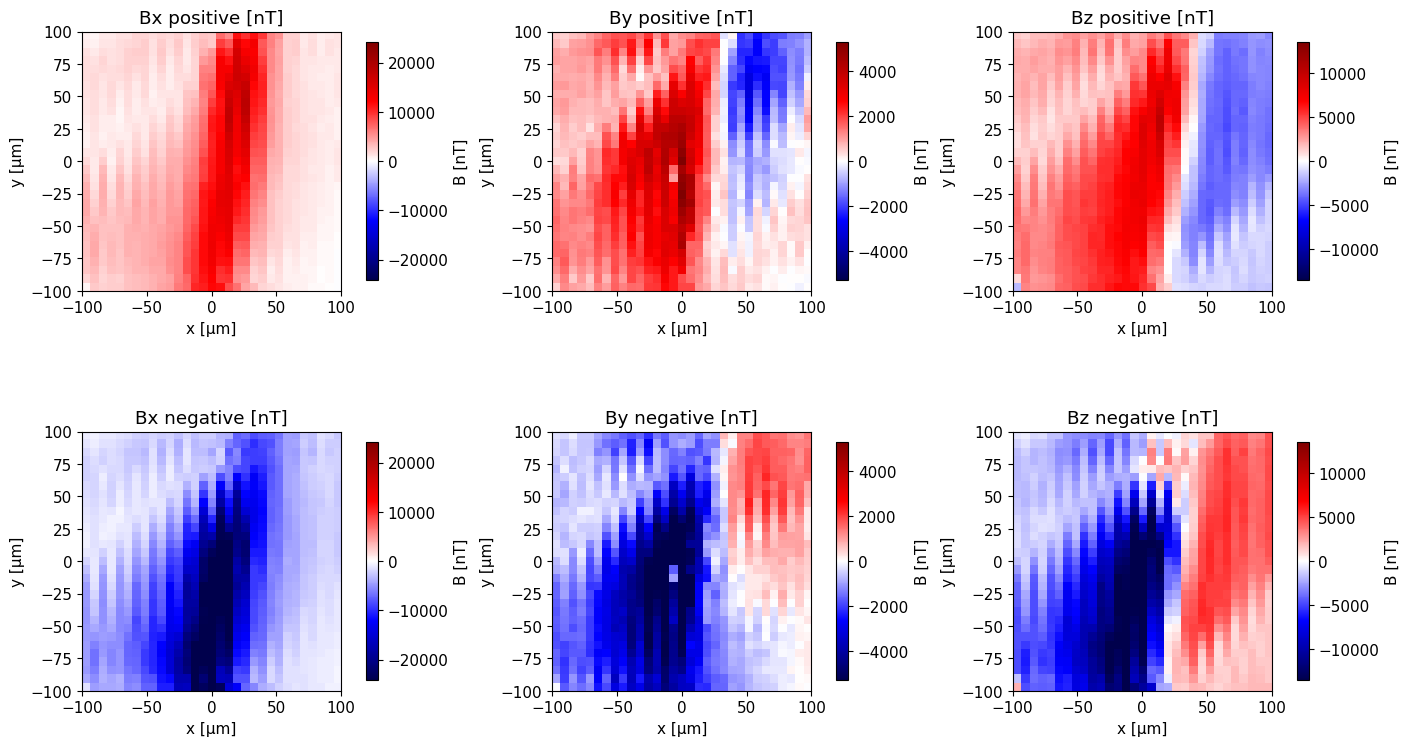

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_nT[i]), 95),
        np.nanpercentile(np.abs(B_neg_nT[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_nT[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"{comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04).set_label("B [nT]")

    im1 = axes[1, i].imshow(
        B_neg_nT[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"{comp} negative [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04).set_label("B [nT]")

plt.show()

In [4]:
def reconstruct_sheet_current_from_Bxyz(
    Bx_nT,
    By_nT,
    Bz_nT,
    dx_m,
    dy_m,
    stand_off_um,
    k_filter_fraction=0.35,
    regularization=1e-3,
):
    """
    Reconstruct 2D sheet current density Kx, Ky from measured Bx, By, Bz.

    Inputs:
        Bx_nT, By_nT, Bz_nT : measured magnetic-field maps [nT]
        dx_m, dy_m          : pixel spacing [m]
        stand_off_um        : sensor-to-current distance [µm]
        k_filter_fraction   : low-pass filtering fraction of Nyquist k
        regularization      : Tikhonov stabilization strength

    Outputs:
        Kx_A_per_m, Ky_A_per_m, Kmag_A_per_m
    """

    Bx_T = Bx_nT * 1e-9
    By_T = By_nT * 1e-9
    Bz_T = Bz_nT * 1e-9

    ny, nx = Bx_T.shape

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx_m)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy_m)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    h_m = stand_off_um * 1e-6

    Bx_k = np.fft.fft2(Bx_T)
    By_k = np.fft.fft2(By_T)
    Bz_k = np.fft.fft2(Bz_T)

    k_nyquist = np.pi / min(dx_m, dy_m)
    k_cut = k_filter_fraction * k_nyquist
    filt = np.exp(-(K / k_cut)**4)
    filt[0, 0] = 0.0

    Kx_k = np.zeros_like(Bx_k, dtype=complex)
    Ky_k = np.zeros_like(By_k, dtype=complex)

    for iy in range(ny):
        for ix in range(nx):
            k = K[iy, ix]

            if k == 0:
                Kx_k[iy, ix] = 0.0
                Ky_k[iy, ix] = 0.0
                continue

            kx_val = KX[iy, ix]
            ky_val = KY[iy, ix]

            pref = 0.5 * mu0 * np.exp(-k * h_m)

            # B = G @ [Kx, Ky]
            G = pref * np.array([
                [0.0, -1.0],
                [1.0,  0.0],
                [-1j * ky_val / k, 1j * kx_val / k],
            ], dtype=complex)

            b = np.array([
                Bx_k[iy, ix],
                By_k[iy, ix],
                Bz_k[iy, ix],
            ], dtype=complex)

            # Tikhonov-stabilized least squares:
            # solve (G^H G + lambda I) K = G^H b
            GH_G = G.conj().T @ G
            GH_b = G.conj().T @ b

            lam = regularization * np.trace(GH_G).real / 2
            A = GH_G + lam * np.eye(2)

            K_solution = np.linalg.solve(A, GH_b)

            Kx_k[iy, ix] = K_solution[0] * filt[iy, ix]
            Ky_k[iy, ix] = K_solution[1] * filt[iy, ix]

    Kx = np.real(np.fft.ifft2(Kx_k))
    Ky = np.real(np.fft.ifft2(Ky_k))
    Kmag = np.sqrt(Kx**2 + Ky**2)

    return Kx, Ky, Kmag

In [5]:
Bx_current_nT = B_odd_nT[0]
By_current_nT = B_odd_nT[1]
Bz_current_nT = B_odd_nT[2]

STAND_OFF_UM = 35.0
K_FILTER_FRACTION = 0.35
REGULARIZATION = 1e-3

Kx_A_per_m, Ky_A_per_m, Kmag_A_per_m = reconstruct_sheet_current_from_Bxyz(
    Bx_nT=Bx_current_nT,
    By_nT=By_current_nT,
    Bz_nT=Bz_current_nT,
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
    regularization=REGULARIZATION,
)

print("All-component current reconstruction")
print("------------------------------------")
print("STAND_OFF_UM:", STAND_OFF_UM)
print("K_FILTER_FRACTION:", K_FILTER_FRACTION)
print("REGULARIZATION:", REGULARIZATION)
print("Kx p95 [A/m]:", np.nanpercentile(np.abs(Kx_A_per_m), 95))
print("Ky p95 [A/m]:", np.nanpercentile(np.abs(Ky_A_per_m), 95))
print("|K| p95 [A/m]:", np.nanpercentile(Kmag_A_per_m, 95))

All-component current reconstruction
------------------------------------
STAND_OFF_UM: 35.0
K_FILTER_FRACTION: 0.35
REGULARIZATION: 0.001
Kx p95 [A/m]: 108.76689956826125
Ky p95 [A/m]: 178.57364719548644
|K| p95 [A/m]: 216.481260758857


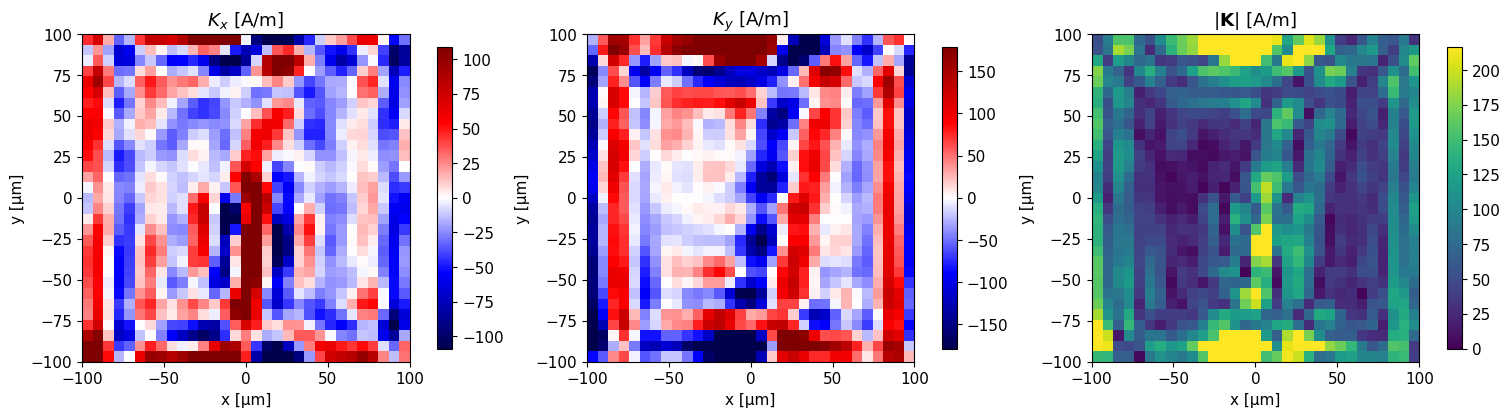

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

maps = [
    (Kx_A_per_m, r"$K_x$ [A/m]", CMAP),
    (Ky_A_per_m, r"$K_y$ [A/m]", CMAP),
    (Kmag_A_per_m, r"$|\mathbf{K}|$ [A/m]", "viridis"),
]

for ax, (data, title, cmap) in zip(axes, maps):
    if "mathbf" in title:
        vmin = 0
        vmax = np.nanpercentile(data, 95)
    else:
        lim = np.nanpercentile(np.abs(data), 95)
        vmin = -lim
        vmax = lim

    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()